# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn import metrics

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

## Exploratory Data Analysis 

In [3]:
# Lectura datos, relación variables, mapas de correlación...
df_advertising = pd.read_csv('data/Advertising.csv', index_col = 0)
df_advertising

,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
...,...,...,...,...
195,38.2,3.7,13.8,7600.0
196,94.2,4.9,8.1,9700.0
197,177.0,9.3,6.4,12800.0
198,283.6,42.0,66.2,25500.0


In [4]:
df_advertising.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    object 
 3   sales     200 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.8+ KB


In [6]:
# Transformamos la columna Newspaper de Objeto a Número
valor_a_sustituir = '6s9.2'
nuevo_valor = 69.2

df_advertising['newpaper'] = df_advertising['newpaper'].replace(valor_a_sustituir, nuevo_valor)

df_advertising['newpaper'] = pd.to_numeric(df_advertising['newpaper'])

In [7]:
df_advertising.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    float64
 3   sales     200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [8]:
df_advertising.describe()

,TV,radio,newpaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14022.500000
std,85.854236,14.846809,21.778621,5217.456566
min,0.700000,0.000000,0.300000,1600.000000
25%,74.375000,9.975000,12.750000,10375.000000
50%,149.750000,22.900000,25.750000,12900.000000
75%,218.825000,36.525000,45.100000,17400.000000
max,296.400000,49.600000,114.000000,27000.000000


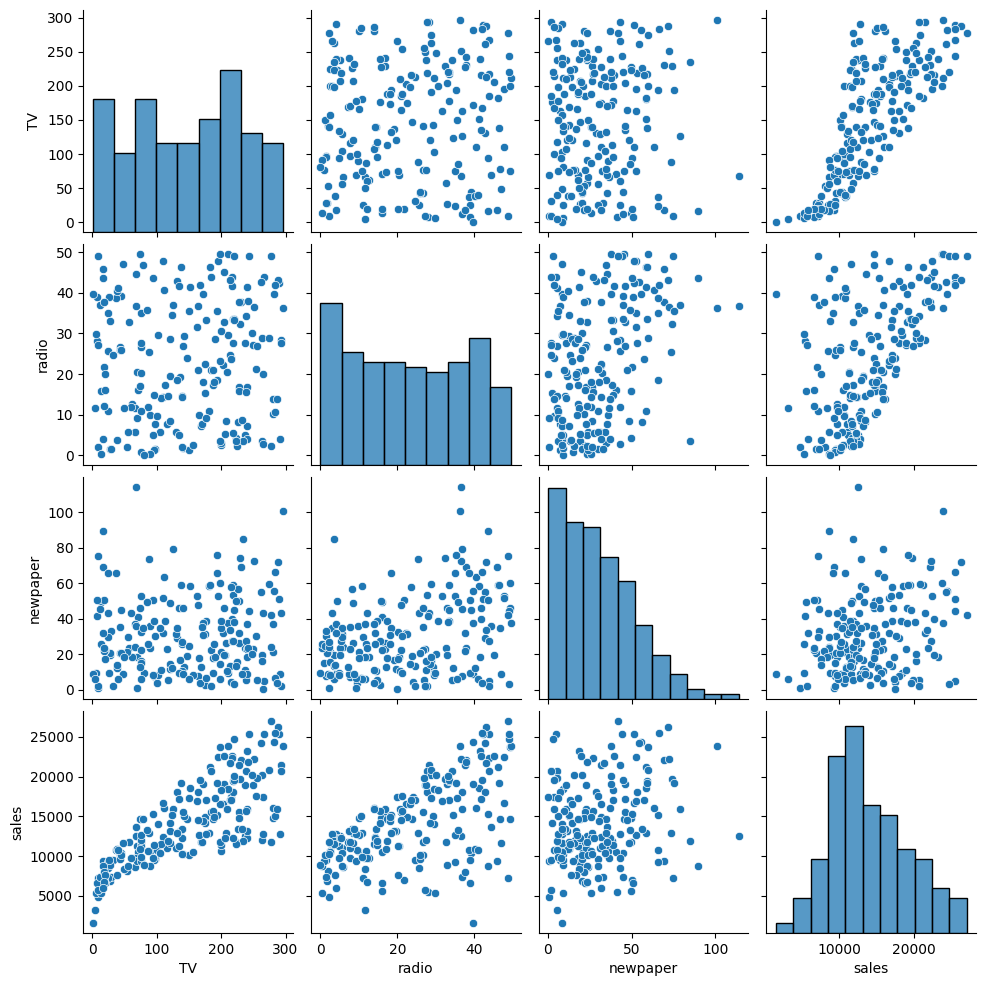

In [ ]:
# GRAFICAMOS PARA VER LAS RELACIONES
sns.pairplot(df_advertising);

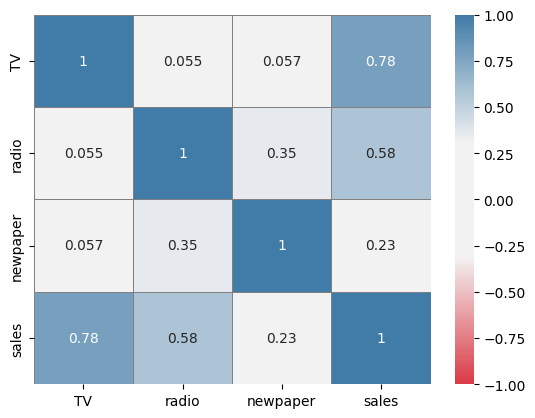

In [11]:
# GRAFICAMOS PARA VER LAS RELACIONES CON HEATMAP
cmap = sns.diverging_palette(10, 240, sep=80, as_cmap=True)
sns.heatmap(df_advertising.corr(numeric_only=True), annot=True, cmap=cmap, center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="gray");


## Modelado

### REGRESION LINEAL

In [61]:
# 1 GENERAMOS LA REGERESION LINEAL NOS QUEDAMOS CON RADIO Y TELEVISIÓN QUE SON LOS QUE TIENEN MÁS RELACION
X = df_advertising[['TV', 'radio', 'newpaper']]
y = df_advertising['sales']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

In [63]:
linear_modelo = LinearRegression()
linear_modelo.fit(X_train, y_train)

LinearRegression()

In [74]:
# COMPROBAMOS
predicciones = linear_modelo.predict (X_test)

print('MAE:', metrics.mean_absolute_error(y_test, predicciones))
print('MAPE', metrics.mean_absolute_percentage_error(y_test, predicciones))
print('MSE:', metrics.mean_squared_error(y_test, predicciones)) # BASELINE ERROR
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predicciones))) 
print('score train',linear_modelo.score(X_train, y_train))
print('score test',linear_modelo.score(X_test, y_test)) 


baseline_error = metrics.mean_squared_error(y_test, predicciones)  
baseline_error 

MAE: 1885.0130310423156
MAPE 0.30155351727176
MSE: 6700486.756528875
RMSE: 2588.5298446278102
score train 0.9209087553499528
score test 0.8353672324670594


6700486.756528875

In [21]:
# HACEMOS UNA PREDICCION A MANO
pred_final = linear_modelo.predict ([[20.2, 15.6, 2.4]])
print (pred_final)

[7150.50917697]


c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


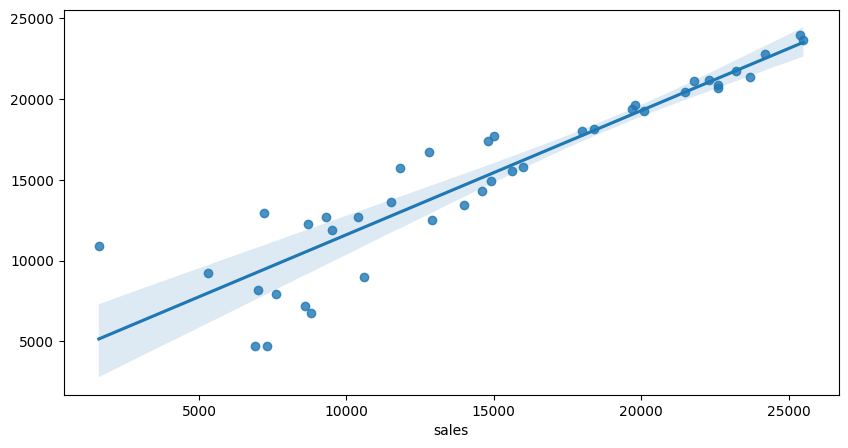

In [17]:
# GRAFICAMOS
plt.figure(figsize = [10,5])
sns.regplot(x = y_test, y = predicciones);

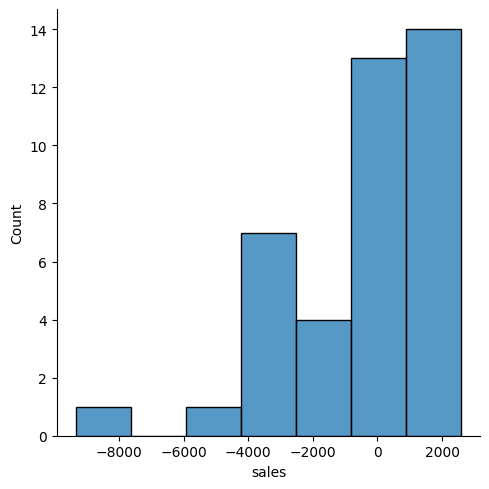

In [18]:
sns.displot((y_test - predicciones));

### REGRESION POLINOMICA

In [25]:
X = df_advertising[['TV', 'radio', 'newpaper']]
y = df_advertising['sales']

In [32]:
poly_feats = PolynomialFeatures(degree = 4)
poly_feats.fit(X_train)
X_train_poly = poly_feats.transform(X_train)
X_test_poly = poly_feats.transform(X_test)

In [33]:
pol_reg = LinearRegression()
pol_reg.fit(X_train_poly, y_train)

LinearRegression()

In [34]:
# COMPROBAMOS
pred_poly = pol_reg.predict(X_test_poly)

print('MAE:', metrics.mean_absolute_error(y_test, pred_poly))
print('MAPE', metrics.mean_absolute_percentage_error(y_test, pred_poly))
print('MSE:', metrics.mean_squared_error(y_test, pred_poly))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_poly)))
print('score train',pol_reg.score(X_train_poly, y_train))
print('score test',pol_reg.score(X_test_poly, y_test))      

MAE: 418.9545359206638
MAPE 0.09422907373520603
MSE: 611359.1231374765
RMSE: 781.8945729044783
score train 0.9961685165400372
score test 0.9849787413876219


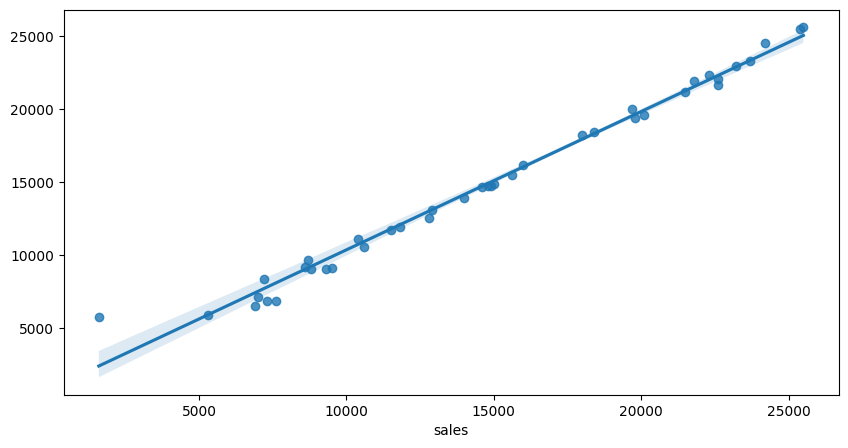

In [35]:
# GRAFICAMOS
plt.figure(figsize = [10,5])
sns.regplot(x = y_test, y = pred_poly);

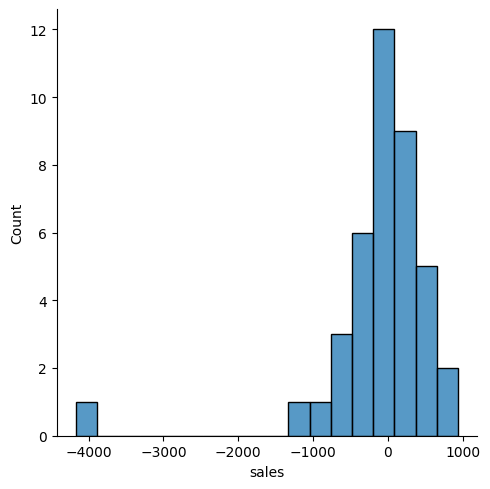

In [36]:
sns.displot((y_test - pred_poly));

#### Debemos de aumentar o reducir la la complejidad de nuestros modelos?

Debemos reducir la complejidad, porque nos sale un score del 99% lo que nos indica un Overfiting.  
Hacemos regularización

## NORMALIZAMOS


In [ ]:
# NO ES MUY UTIL
st_scaler = StandardScaler ()
st_scaler.fit(X_train)
X_train_scaler = st_scaler.transform(X_train)
X_test_scaler = st_scaler.transform(X_test)

In [24]:
# PROBAMOS EN EL MODELO LINEAL
linear_modelo.fit (X_train_scaler, y_train)

pred_scaler = linear_modelo.predict (X_test_scaler )

print('MAE:', metrics.mean_absolute_error(y_test, pred_scaler))
print('MAPE', metrics.mean_absolute_percentage_error(y_test, pred_scaler))
print('MSE:', metrics.mean_squared_error(y_test, pred_scaler)) # BASELINE ERROR
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_scaler))) 
print('score train',linear_modelo.score(X_train_scaler, y_train))
print('score test',linear_modelo.score(X_test_scaler, y_test)) 

MAE: 1885.013031042316
MAPE 0.30155351727176016
MSE: 6700486.7565288795
RMSE: 2588.529844627811
score train 0.9209087553499528
score test 0.8353672324670592


## RIDGE

In [101]:
X = df_advertising[['TV', 'radio', 'newpaper']]
y = df_advertising['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

ridgeR = Ridge(alpha = 63)
ridgeR.fit(X_train, y_train)

pred_ridge = ridgeR.predict(X_test)
pred_ridge1 = ridgeR.predict(X_train)

print("Train MSE con regularización:", metrics.mean_squared_error(y_train, pred_ridge1))
print("Test MSE con regularización:", metrics.mean_squared_error(y_test, pred_ridge))

Train MSE con regularización: 1858627.48097089
Test MSE con regularización: 6696772.212688309


In [ ]:
n_alphas = 100
alphas = np.logspace(-4, 3, n_alphas)  

coef_ridge = []
err_ridge = []
baseline = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    
    # coef_ridge.append(ridge.coef_)
    
    y_pred = ridge.predict(X_test)
    ridge_error = metrics.mean_squared_error(y_test, y_pred)
    
    err_ridge.append(ridge_error)
    baseline.append(baseline_error)

np.array(err_ridge).argmin()

np.int64(99)

In [40]:
min(err_ridge)

6651212.213048748

In [102]:
# HACEMOS EL BUCLE PERO CON UN METODO QUE YA EXISTE LLAMADO GRIDSEARCH
from sklearn.model_selection import GridSearchCV

# HACEMOS REGRESION POLINOMIAL
pl_r = PolynomialFeatures (degree=2)
pl_r.fit(X_train, y_train)
pl_r_train = pl_r.transform(X_train)
pl_r_test = pl_r.transform(X_test)

ridge = Ridge()

parametros = {'alpha': np.logspace(-4, 3, n_alphas)}

gs = GridSearchCV(ridge, parametros, scoring = 'neg_mean_absolute_error', cv = 5)
gs.fit(pl_r_train, y_train)



GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': array([1.00000000e-04, 1.17681195e-04, 1.38488637e-04, 1.62975083e-04,
       1.91791026e-04, 2.25701972e-04, 2.65608778e-04, 3.12571585e-04,
       3.67837977e-04, 4.32876128e-04, 5.09413801e-04, 5.99484250e-04,
       7.05480231e-04, 8.30217568e-04, 9.77009957e-04, 1.14975700e-03,
       1.35304777e-03, 1.59228279e-03, 1.87381742e-03, 2....
       2.36448941e+01, 2.78255940e+01, 3.27454916e+01, 3.85352859e+01,
       4.53487851e+01, 5.33669923e+01, 6.28029144e+01, 7.39072203e+01,
       8.69749003e+01, 1.02353102e+02, 1.20450354e+02, 1.41747416e+02,
       1.66810054e+02, 1.96304065e+02, 2.31012970e+02, 2.71858824e+02,
       3.19926714e+02, 3.76493581e+02, 4.43062146e+02, 5.21400829e+02,
       6.13590727e+02, 7.22080902e+02, 8.49753436e+02, 1.00000000e+03])},
             scoring='neg_mean_absolute_error')

In [103]:
modelo_final = gs.best_estimator_

In [104]:
gs.best_estimator_


Ridge(alpha=np.float64(1000.0))

## LASSO

In [105]:
lassoR = Lasso(alpha=0.5)
lassoR.fit(X_train, y_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, linear_modelo.predict(X_train)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, linear_modelo.predict(X_test)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, lassoR.predict(X_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, lassoR.predict(X_test)))

Train MSE sin regularización: 1858596.67
Test MSE sin regularización: 6700486.76
Train MSE: 1858596.6735
Test MSE: 6700468.0177


In [106]:
from sklearn  import linear_model
lasso = linear_model.Lasso(fit_intercept=False)

n_alphal = 100
alphal = np.logspace(-4, 3, n_alphal) 

coef_lasso = []
err_lasso = []

for a in alphal:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coef_lasso.append(lasso.coef_)
    y_pred = lasso.predict(X_test)
    lasso_error = metrics.mean_squared_error(y_pred, y_test)    
    err_lasso.append(lasso_error)
    
np.array(err_lasso).argmin()

np.int64(99)

In [107]:
np.array(coef_lasso).argmin()

np.int64(299)

## Resultados

In [112]:
print("Linear regression error:   %0.4f" % baseline_error)
print('polinomial regression error:', (metrics.mean_squared_error(y_test, pred_poly)))
print("Minimun ridge error:       %0.4f" % min(err_ridge))
print("Minimum lasso error:       %0.4f" % min(err_lasso))

Linear regression error:   6700486.7565
polinomial regression error: 611359.1231374765
Minimun ridge error:       6651212.2130
Minimum lasso error:       6728993.6033


In [35]:
# NO SE INTERPRETAR LOS RESULTADOS